In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/TCGA Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((496, 19277), (124, 19277), (496,), (124,))


Calculating SHAP values...
SHAP values shape: (124, 100, 5)
Selected features: 100

=== Overall Top 10 Features ===
     Feature  MeanAbsSHAP_MaxAcrossSubtypes
75    ABCC11                       0.033333
3     AXDND1                       0.028456
1      LEMD1                       0.022520
57       CIT                       0.022260
56   MIR1178                       0.021530
33    OSGIN2                       0.021469
85     GPR77                       0.019626
97      TFF1                       0.017694
53      TMPO                       0.017184
58  TMEM132B                       0.016612


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_17616\2835979875.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


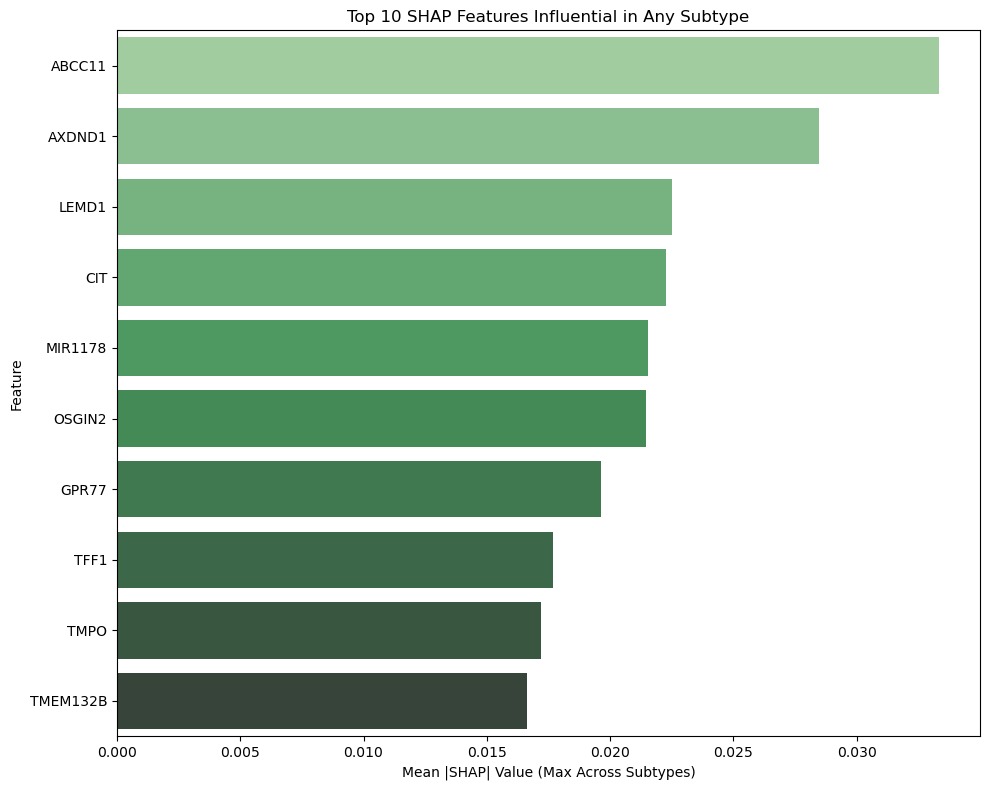

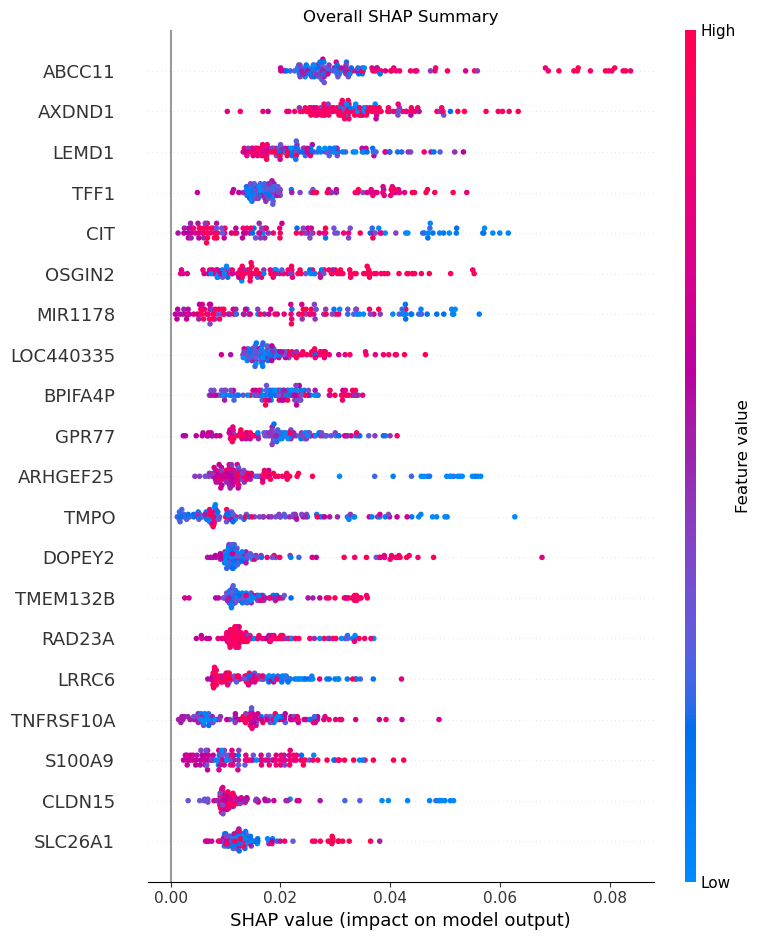


Subtype 1: Basal
         Feature  MeanAbsSHAP
75        ABCC11     0.033333
3         AXDND1     0.017694
97          TFF1     0.017025
87        RAD23A     0.016088
76     LOC440335     0.015612
98        DOPEY2     0.014974
15       SLC26A1     0.013761
37     LOC727677     0.012286
60         REP15     0.009477
74  LOC100129637     0.009000


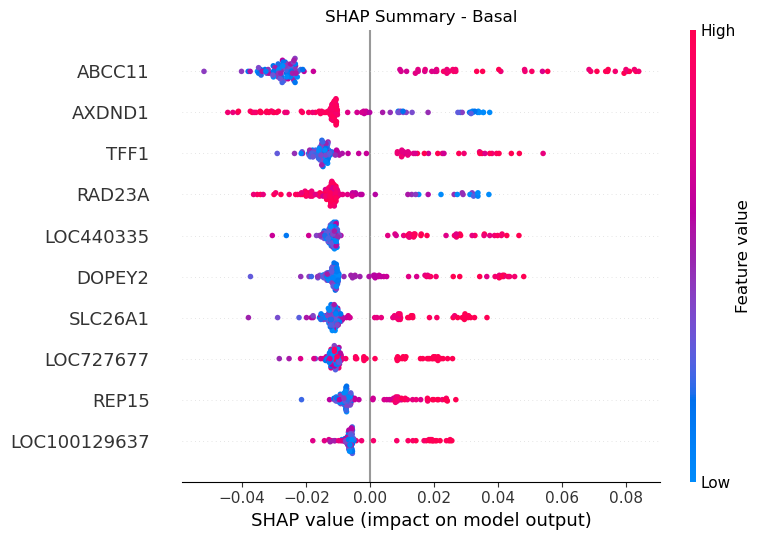

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_17616\2835979875.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


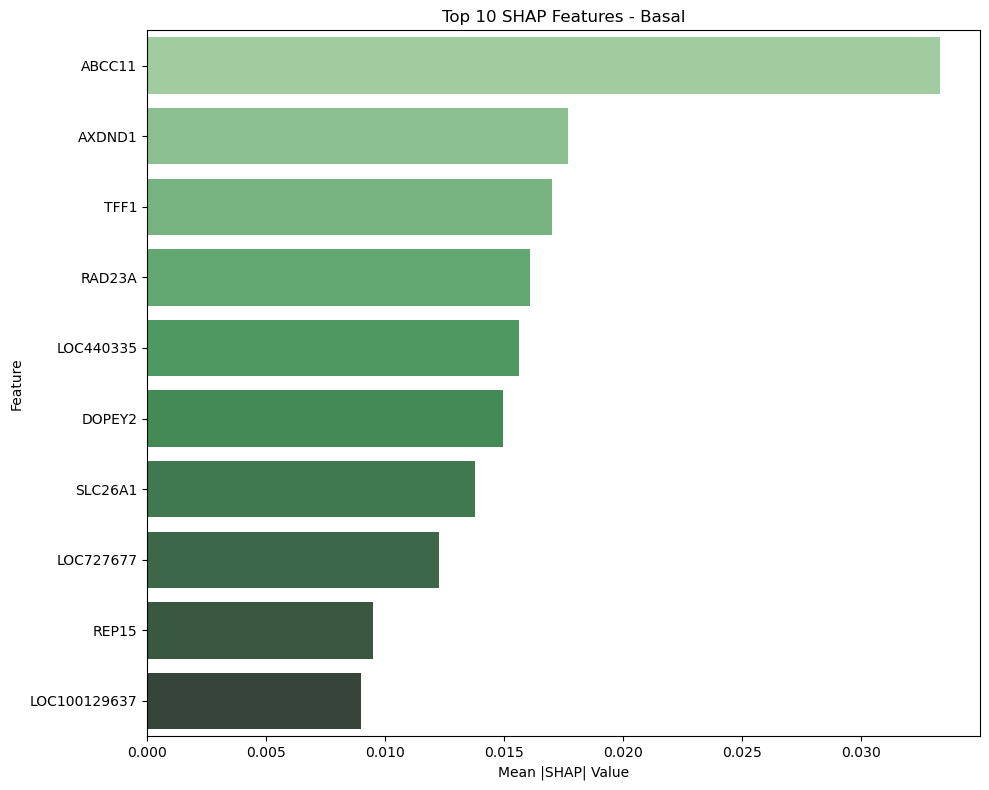


Subtype 2: Her2
      Feature  MeanAbsSHAP
3      AXDND1     0.028456
1       LEMD1     0.022520
75     ABCC11     0.020914
85      GPR77     0.019626
97       TFF1     0.017694
33     OSGIN2     0.015139
0       PRUNE     0.014108
98     DOPEY2     0.013218
34  TNFRSF10A     0.012515
38      LRRC6     0.011911


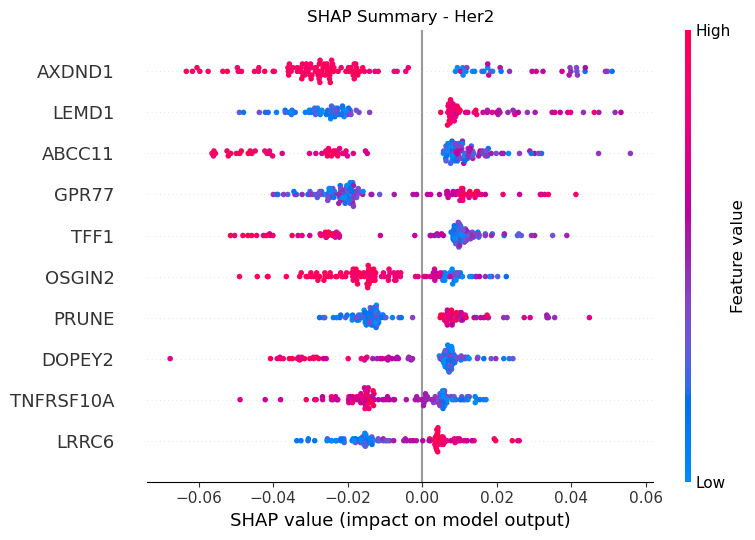

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_17616\2835979875.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


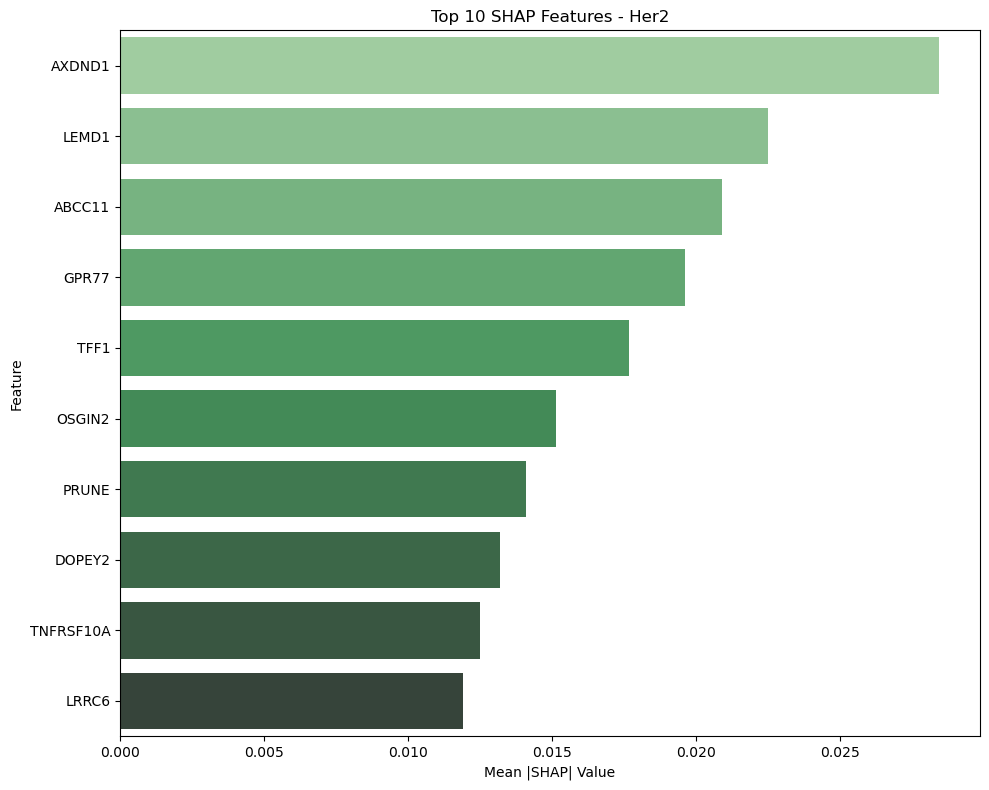


Subtype 3: LumA
      Feature  MeanAbsSHAP
3      AXDND1     0.026886
57        CIT     0.022260
56    MIR1178     0.021530
33     OSGIN2     0.021469
53       TMPO     0.017184
75     ABCC11     0.015535
34  TNFRSF10A     0.014099
1       LEMD1     0.014086
2      S100A9     0.013730
47      HSPB2     0.013251


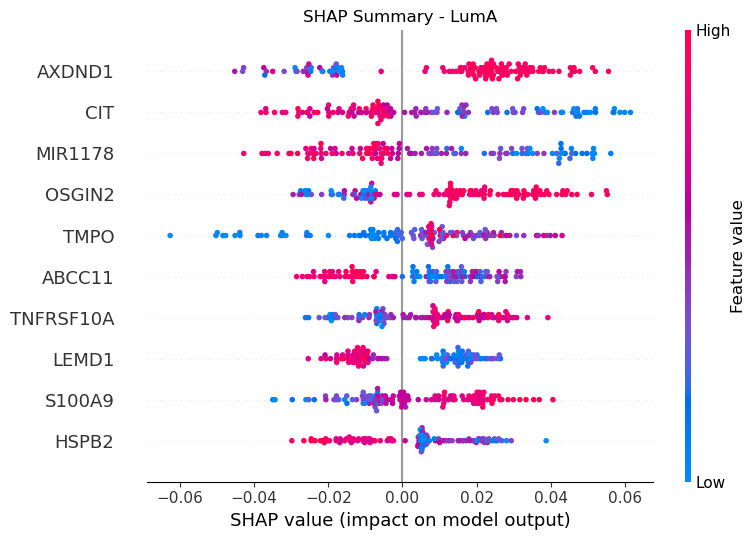

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_17616\2835979875.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


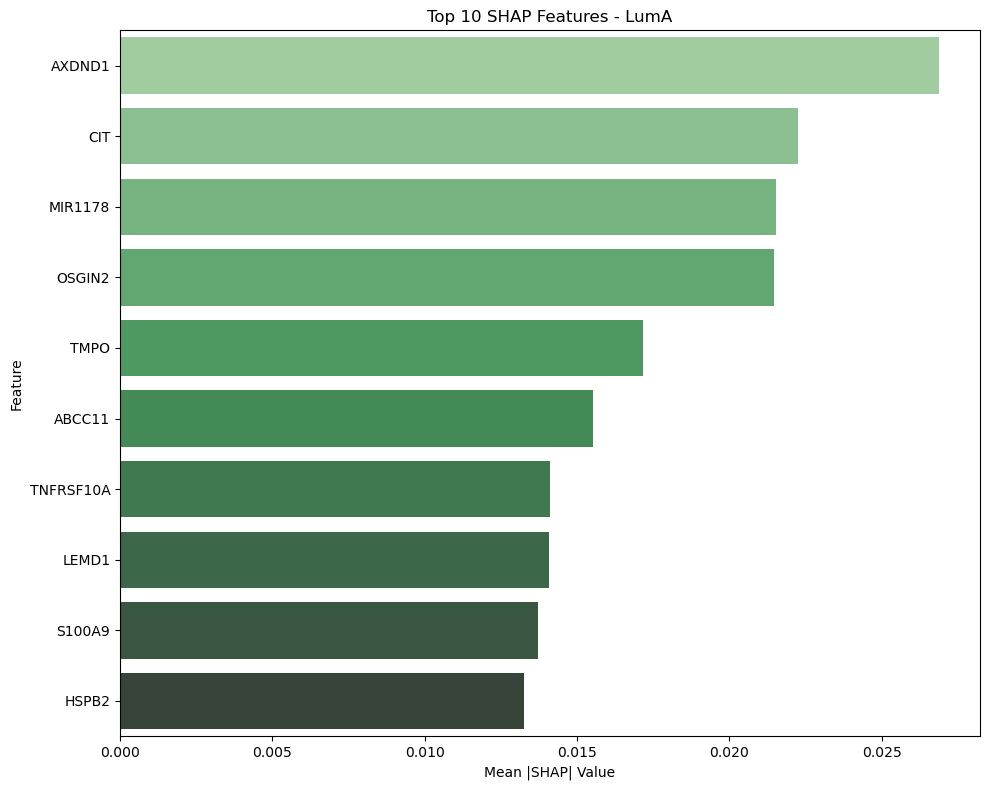


Subtype 4: LumB
      Feature  MeanAbsSHAP
1       LEMD1     0.021228
57        CIT     0.017452
56    MIR1178     0.016062
53       TMPO     0.015871
38      LRRC6     0.015300
75     ABCC11     0.014939
91    BPIFA4P     0.013778
47      HSPB2     0.013163
76  LOC440335     0.011055
85      GPR77     0.010240


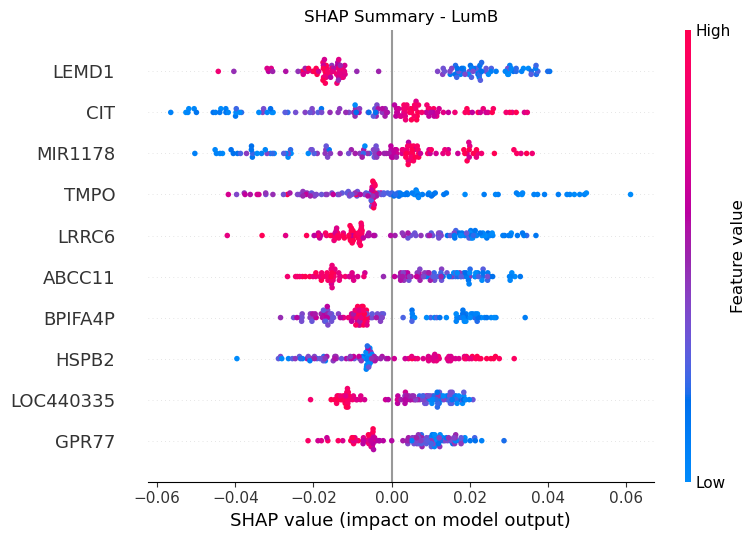

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_17616\2835979875.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


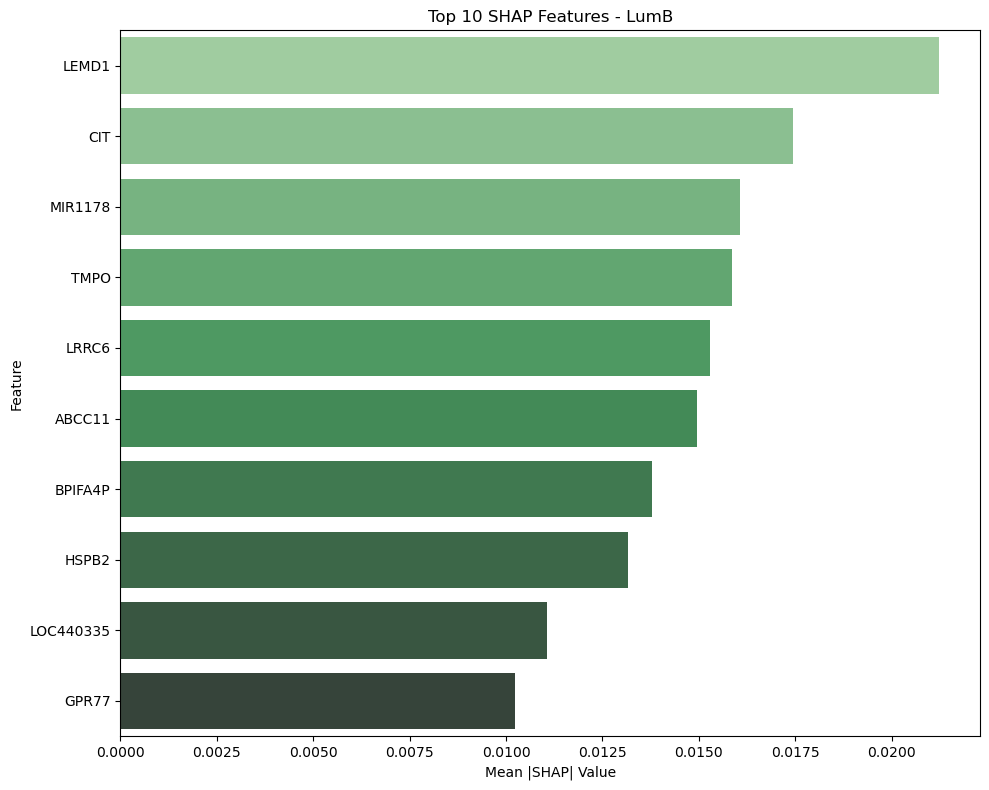


Subtype 5: Normal
      Feature  MeanAbsSHAP
75     ABCC11     0.018020
97       TFF1     0.017016
58   TMEM132B     0.016612
51   ARHGEF25     0.015664
31     CLDN15     0.014675
76  LOC440335     0.012796
91    BPIFA4P     0.012351
3      AXDND1     0.011960
69     ZNF106     0.011543
62       SOX1     0.009167


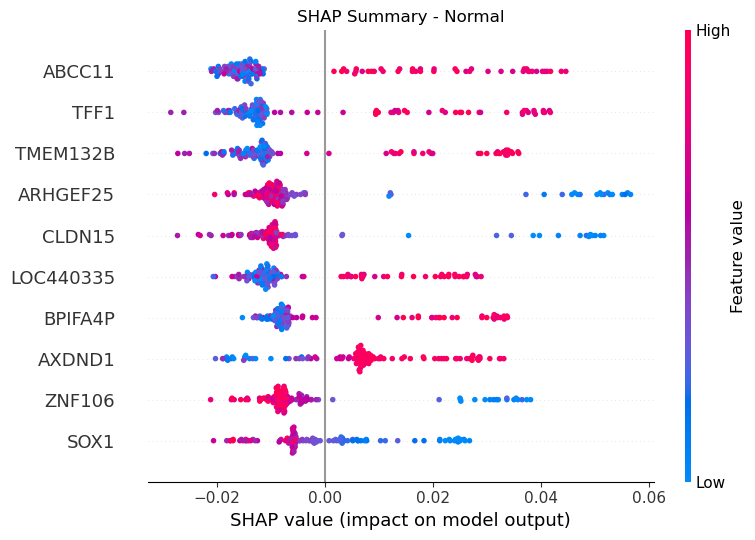

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_17616\2835979875.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


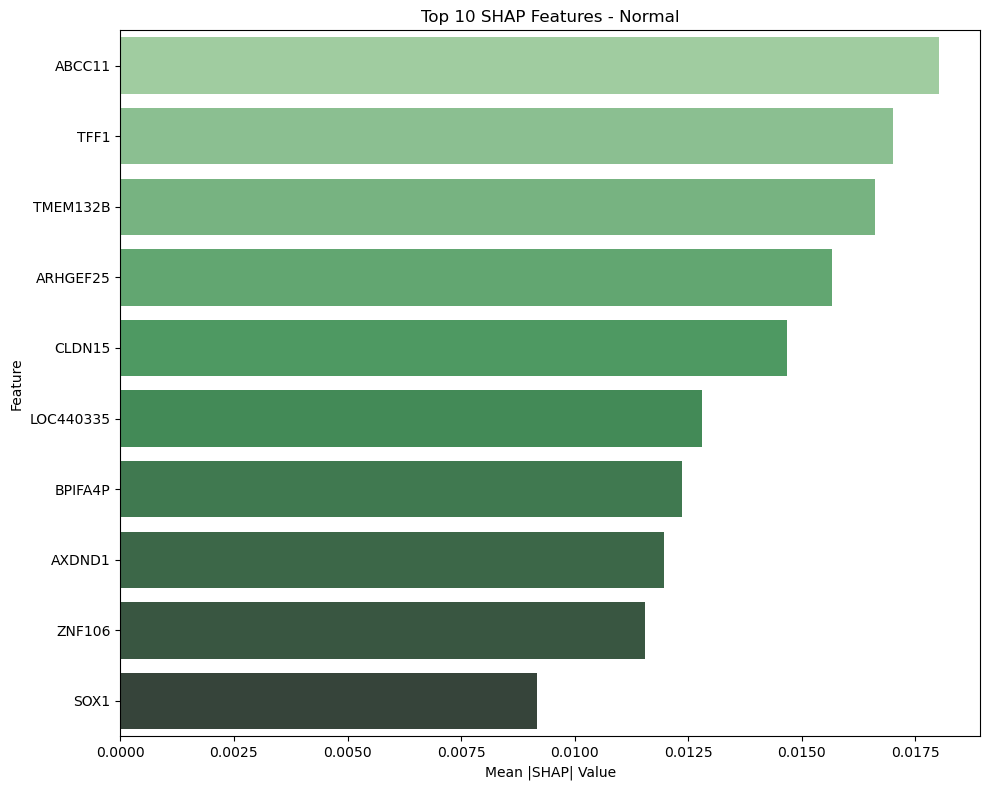


SHAP analysis complete — both overall and per-subtype results generated.


In [3]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_TCGA_SMOTE_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']
scaler = pipeline_model.named_steps['scaler']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

# Scale test set
X_test_scaled = scaler.transform(X_test)
X_test_selected = X_test_scaled[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")